## First we analyze the ALA as a function of iteration.

Each iteration contains an unfiltered 1000 new images, 

yet each new iteration also contains the previous iteration's images.

Hence in total we have $\sum_{i=1}^{i=10} 1000i = 55,000$ images.

While only 10,000 of these images are unique ($1000$ images $\times$ $10$ iterations), 

Each iteration's neural network (NN) will infer distinct values for its images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

In [2]:
all_images = read('../../TIME/JUN/TB5-10.xyz', index=':')
len(all_images)

55000

In [3]:
iterations = [[i for i in all_images if i.info['Iteration']==it] for it in range(10)]
[len(i) for i in iterations]

[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

### Each image contains key-value dictionaries in its ```image.info``` and ```image.arrays``` attributes.

In [4]:
image = all_images[0]
image.info, image.arrays

({'DFT_Energy': np.float64(-10237.52451889),
  'NN_Energy': np.float64(-10238.068439812365),
  'Index': np.int64(2709),
  'Adsorbate': 'NH3',
  'DFT_E_ads': np.float64(0.010404089998765187),
  'NN_E_ads': np.float64(0.043619790573384165),
  'E_ads_Error': np.float64(0.03321570057461898),
  'Iteration': np.int64(0),
  'Split': 'train',
  'Nearest_Neighbor_Distance': np.float64(2.926958444477817),
  'Nearest_Neighbor_Element': 'Pt',
  'Adsorbate_Site': 'bridge',
  'Entropy': np.float64(6.0),
  'Cluster_Size': np.int64(30),
  'DFT_Cluster_Energy': np.float64(-10217.3795636),
  'NN_Cluster_Energy': np.float64(-10217.961312188647),
  'DFT_Adsorbate_Energy': np.float64(-20.15535938),
  'NN_Adsorbate_Energy': np.float64(-20.06350783314466),
  'Energy_Error': np.float64(0.5439209223641228)},
 {'numbers': array([47, 47, 47, 79, 79, 79, 79, 79, 29, 29, 29, 29, 28, 28, 28, 28, 28,
         28, 28, 46, 46, 46, 46, 46, 46, 78, 78, 78, 78, 78,  7,  1,  1,  1]),
  'positions': array([[13.87241, 11.25

### With the help of a parsing function, we can extract useful values for our analysis.

In [5]:
import pandas as pd

def Parse_Iteration(images, iteration, outlier_thresh=10.0, verbose=False):
    '''Parses a list of images to calculate core error metrics for NN predictions.'''
    
    splits = ['train', 'valid', 'test']
    targets = ['E', 'F', 'E_ads']
    
    # 1. Dynamically initialize the storage architecture
    data = {s: {t: {'ref': [], 'pred': []} for t in targets} for s in splits}
    invalid_count = 0
    
    for atoms in images:
        
        # Fails fast with KeyError if 'split' is missing
        split = atoms.info['Split']
        if split not in data:
            raise ValueError(f'Unexpected split value: {split}. Expected train, valid, or test.')
            
        # Extract per-atom normalized energies
        n_atoms = len(atoms)
        ref_e = atoms.info['DFT_Energy'] / n_atoms
        pred_e = atoms.info['NN_Energy'] / n_atoms
        
        # Extract flattened forces
        ref_f = atoms.arrays['DFT_Forces'].ravel()
        pred_f = atoms.arrays['NN_Forces'].ravel()        
        
        # Extract adsorption energies
        ref_e_ads = atoms.info['DFT_E_ads']
        pred_e_ads = atoms.info['NN_E_ads']
        
        # Outlier shield
        if abs(ref_e - pred_e) >= outlier_thresh or np.max(np.abs(ref_f - pred_f)) >= outlier_thresh:
            invalid_count += 1
            continue
            
        # Store values
        data[split]['E']['ref'].append(ref_e)
        data[split]['E']['pred'].append(pred_e)
        data[split]['F']['ref'].extend(ref_f)
        data[split]['F']['pred'].extend(pred_f)
        data[split]['E_ads']['ref'].append(ref_e_ads)
        data[split]['E_ads']['pred'].append(pred_e_ads)
            
    if verbose and invalid_count > 0:
        print(f'Iteration {iteration}: Dropped {invalid_count} outliers.')
        
    row = {'Iteration': iteration}
    
    # 2. Vectorized Metric Calculation
    for split in splits:
        prefix = split.capitalize()
        
        for target in targets:
            col_base = f'{prefix}_{target}'
            
            ref = np.array(data[split][target]['ref'])
            pred = np.array(data[split][target]['pred'])
            n = len(ref)
            
            if n == 0:
                row[f'{col_base}_RMSE'] = 0.0
                row[f'{col_base}_MAE'] = 0.0
                row[f'{col_base}_SD'] = 0.0
                row[f'{col_base}_CI_95'] = 0.0
                continue
                
            errors = pred - ref
            abs_errors = np.abs(errors)
            
            # Core Metrics
            row[f'{col_base}_RMSE'] = np.round(np.sqrt(np.mean(errors**2)), 5)
            row[f'{col_base}_MAE'] = np.round(np.mean(abs_errors), 5)
            
            # Rigorous Statistics 
            sd = np.std(abs_errors, ddof=1) if n > 1 else 0.0
            row[f'{col_base}_SD'] = np.round(sd, 5)
            row[f'{col_base}_CI_95'] = np.round(1.96 * (sd / np.sqrt(n)), 5)
            
    return row

In [6]:
dataframe = pd.DataFrame([Parse_Iteration(images, i) for i, images in enumerate(iterations)])
dataframe

,Iteration,Train_E_RMSE,Train_E_MAE,Train_E_SD,Train_E_CI_95,Train_F_RMSE,Train_F_MAE,Train_F_SD,Train_F_CI_95,Train_E_ads_RMSE,...,Test_E_SD,Test_E_CI_95,Test_F_RMSE,Test_F_MAE,Test_F_SD,Test_F_CI_95,Test_E_ads_RMSE,Test_E_ads_MAE,Test_E_ads_SD,Test_E_ads_CI_95
0,0,0.02786,0.02209,0.01698,0.00126,0.12925,0.09071,0.09207,0.00067,0.38501,...,0.01344,0.00263,0.15229,0.09926,0.11550,0.00222,0.34834,0.23069,0.26231,0.05141
1,1,0.02009,0.01654,0.01141,0.00060,0.11552,0.08032,0.08303,0.00043,0.22853,...,0.01450,0.00197,0.12701,0.08594,0.09352,0.00128,0.21260,0.16001,0.14031,0.01907
2,2,0.01980,0.01538,0.01247,0.00053,0.10783,0.07420,0.07825,0.00033,0.19008,...,0.01665,0.00186,0.13026,0.08306,0.10035,0.00110,0.19476,0.14153,0.13402,0.01494
3,3,0.01897,0.01491,0.01172,0.00043,0.10022,0.06743,0.07415,0.00028,0.20131,...,0.01268,0.00127,0.10813,0.07123,0.08135,0.00083,0.20361,0.16033,0.12566,0.01255
4,4,0.01627,0.01274,0.01012,0.00033,0.10007,0.06870,0.07277,0.00024,0.16517,...,0.01064,0.00093,0.11137,0.07507,0.08227,0.00072,0.16841,0.11821,0.12007,0.01049
5,5,0.01423,0.01128,0.00868,0.00026,0.09802,0.06725,0.07131,0.00022,0.14397,...,0.00909,0.00072,0.11130,0.07297,0.08404,0.00068,0.14444,0.10401,0.10030,0.00795
6,6,0.01425,0.01105,0.00899,0.00025,0.09096,0.06113,0.06736,0.00019,0.16531,...,0.01110,0.00082,0.09925,0.06577,0.07433,0.00056,0.15793,0.11294,0.11046,0.00811
7,7,0.01606,0.01216,0.01049,0.00027,0.09244,0.06308,0.06758,0.00018,0.15267,...,0.00936,0.00066,0.10235,0.06867,0.07590,0.00054,0.14769,0.10869,0.10005,0.00702
8,8,0.01375,0.01073,0.00860,0.00021,0.09110,0.06192,0.06682,0.00017,0.13297,...,0.01059,0.00070,0.09650,0.06431,0.07195,0.00048,0.13864,0.09788,0.09823,0.00645
9,9,0.00979,0.00727,0.00655,0.00015,0.07390,0.04885,0.05545,0.00013,0.12028,...,0.00707,0.00044,0.09215,0.05846,0.07124,0.00045,0.12560,0.08896,0.08870,0.00551


### The confidence interval (CI) is defined $C_I = \alpha \frac{\sigma}{\sqrt{N}}$, where $\alpha$ is chosen to represent 95% of the uncertainty.

#### It helps to make a minimal plot to showcase the basic trends.

In [7]:
from matplotlib.lines import Line2D

def plot_metric_with_ci(df, metric):
    
    metrics = ['E', 'F', 'E_ads']
    if metric not in metrics: 
        print('metric not in', metrics)
        return
    
    plt.figure(figsize=(5,5))
    splits = [('Train', '-'), ('Valid', '--'), ('Test', ':')]
    
    for split, ls in splits:
        
        mae_col = f'{split}_{metric}_MAE'
        ci_col = f'{split}_{metric}_CI_95'
        
        # Plot the main line and grab its assigned color
        line = plt.plot(df['Iteration'], df[mae_col], ls=ls, label=split)[0]
        color = line.get_color()
        
        # Layer the physical error bars
        plt.errorbar(df['Iteration'], df[mae_col], yerr=df[ci_col], 
                    fmt='none', capsize=4, ecolor=color, alpha=0.8)
        
        # Layer the shaded corridor
        plt.fill_between(df['Iteration'], 
                        df[mae_col] - df[ci_col], 
                        df[mae_col] + df[ci_col], 
                        color=color, alpha=0.2)
    plt.grid(ls=':', alpha=0.5)
    plt.xlabel('Iteration')
    plt.ylabel(f'{metric} MAE (with 95% CI)')
    plt.legend(frameon=False)
    plt.show()

def plot_all_maes(df):
    plt.figure(figsize=(5, 5))

    # Capitalized to match the column prefixes generated by get_MAEs
    splits = ['Train', 'Valid', 'Test']
    lines = ['-', '--', ':']
    marks = ['o', '^', 'x']

    for split, mark, line in zip(splits, marks, lines):
        
        x = df['Iteration']
        
        # Directly slice the pre-calculated metrics
        e_ads = df[f'{split}_E_ads_MAE']
        f_err = df[f'{split}_F_MAE']
        e_err = df[f'{split}_E_MAE']

        plt.plot(x, e_ads, c='b', marker=mark, lw=2, ls=line, alpha=0.5)
        plt.plot(x, f_err, c='r', marker=mark, lw=2, ls=line, alpha=0.5)
        plt.plot(x, e_err, c='g', marker=mark, lw=2, ls=line, alpha=0.5)

    legend_keys = [
        Line2D([0], [0], color='gray', lw=2, marker='o', alpha=0.7, label='train'),
        Line2D([0], [0], color='gray', lw=2, ls='--', marker='^', alpha=0.7, label='valid'),
        Line2D([0], [0], color='gray', lw=2, ls=':', marker='x', alpha=0.7, label='test'),
        Line2D([0], [0], color='b', lw=4, alpha=0.7, label='E_ads (eV)'),
        Line2D([0], [0], color='r', lw=4, alpha=0.7, label='Forces (eV/Å)'),
        Line2D([0], [0], color='g', lw=4, alpha=0.7, label='Energy (eV/atom)')
    ]

    plt.legend(handles=legend_keys, loc='upper right', ncol=2, handletextpad=0.5)

    plt.xlabel('Iteration')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(df['Iteration'])
    plt.grid(ls=':', alpha=0.5)
    plt.show()

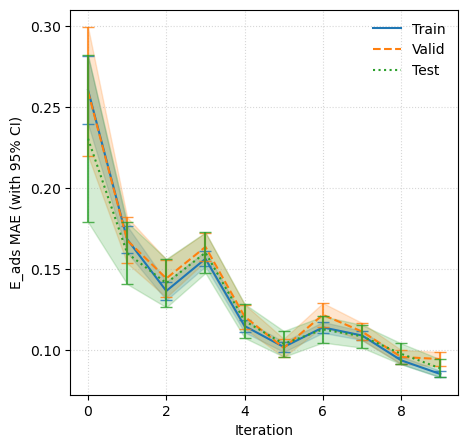

In [8]:
plot_metric_with_ci(dataframe, 'E_ads')

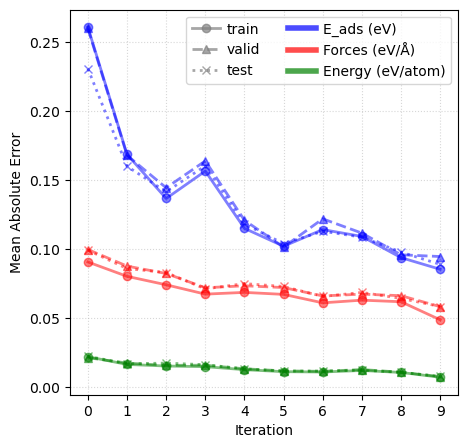

In [9]:
plot_all_maes(dataframe)

## We can also examine each Iteration's performace with parity plots.
For this we do not use the dataframe, but rather access the ASE atom's objects directly.

In [10]:
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde

def get_fast_density(x, y, bins=150, smooth=2.0):
    '''Fast 2D histogram density estimation for massive arrays.'''
    H, xedges, yedges = np.histogram2d(x, y, bins=bins)
    H_smooth = gaussian_filter(H, sigma=smooth)
    
    xidx = np.clip(np.searchsorted(xedges, x) - 1, 0, bins - 1)
    yidx = np.clip(np.searchsorted(yedges, y) - 1, 0, bins - 1)
    
    return H_smooth[xidx, yidx]

def plot_parity(x, y, kind, outlier_thresh=10):
    '''Plots a parity density scatter with smart KDE routing.'''
    
    labels = {
        'e_ads': ('DFT E_ads (eV)', 'NN E_ads (eV)'),        
        'energy': ('DFT Energy (eV/atom)', 'NN Energy (eV/atom)'),
        'forces': ('DFT Forces (eV/Å)', 'NN Forces (eV/Å)')
    }
    
    if kind not in labels:
        raise ValueError(f'Invalid kind: {kind}. Expected one of {list(labels.keys())}.')
        
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    
    # 1. The Outlier Shield
    dropped_count = 0
    if outlier_thresh is not None:
        valid_mask = np.abs(y - x) <= outlier_thresh
        dropped_count = len(x) - np.sum(valid_mask)
        x = x[valid_mask]
        y = y[valid_mask]
        
    if len(x) == 0:
        raise ValueError('Outlier threshold is too strict; all data points were dropped.')
    
    # 2. Metric Calculations on the Filtered Data
    rmse = np.sqrt(np.mean((y - x)**2))
    mae = np.mean(np.abs(y - x))
    span = np.abs(np.max(x) - np.min(x))
    maep = np.round((mae / span) * 100, 3) if span > 0 else 0.0
    
    # 3. Density Estimation
    if kind == 'forces' or len(x) > 5000:
        z = get_fast_density(x, y)
    else:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        
    z = (z - z.min()) / (z.max() - z.min())
    idx = z.argsort()
    x_plot, y_plot, z_plot = x[idx], y[idx], z[idx]

    # 4. Canvas Rendering
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(x_plot, y_plot, c=z_plot, s=15, cmap='turbo', edgecolor='none', alpha=0.75, zorder=2)

    if kind == 'e_ads': 
        lims = [-6.5, 2.5]
        ax.set_xticks(np.linspace(-6, 2, 5))
        ax.set_yticks(np.linspace(-6, 2, 5))
    else:
        min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
        max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
        lims = [min_val, max_val]

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.plot(lims, lims, 'k--', alpha=0.5, zorder=1)
    
    # 5. Dynamic Text Box
    text = f'RMSE: {rmse:.3f}\nMAE: {mae:.3f}\nMAE%: {maep:.2f}'
    text += f'\nDropped: {dropped_count}'
        
    ax.text(0.05, 0.95, text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round, pad=0.3', edgecolor='gray', facecolor='white', alpha=0.75))

    ax.set_xlabel(labels[kind][0])
    ax.set_ylabel(labels[kind][1])
    ax.grid(ls=':', alpha=0.5, zorder=0)
    plt.show()

### Note there are many ways to showcase this dataset

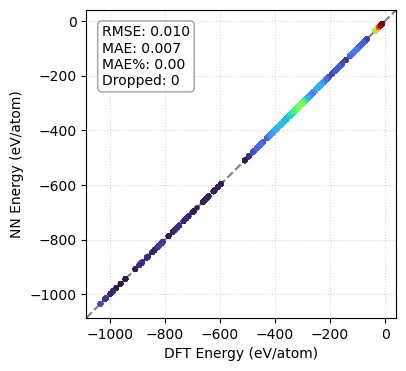

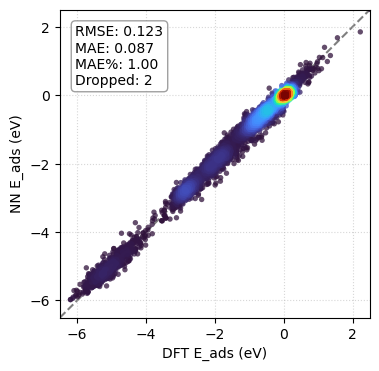

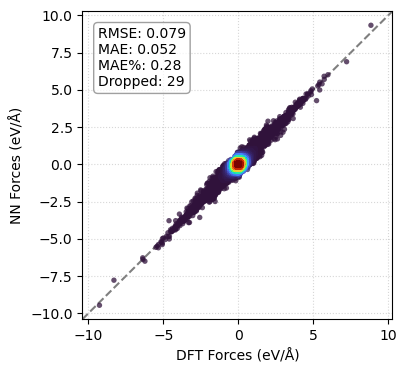

In [11]:
Ex, Ey = [], []
Ax, Ay = [], []
Fx, Fy = [], []

images = iterations[-1]
for i in images:
    Ex.append(i.info['DFT_Energy']/len(i))
    Ey.append(i.info['NN_Energy']/len(i))
    Ax.append(i.info['DFT_E_ads'])
    Ay.append(i.info['NN_E_ads'])
    Fx.extend(i.arrays['DFT_Forces'].ravel())
    Fy.extend(i.arrays['NN_Forces'].ravel())

limit = 1.0
plot_parity(Ex, Ey, kind='energy', outlier_thresh=limit)
plot_parity(Ax, Ay, kind='e_ads', outlier_thresh=limit)
plot_parity(Fx, Fy, kind='forces', outlier_thresh=limit)

### Finally we exemplify some basica per adsorbate analysis
Note for this we are using the final iteration's images (10k)

In [12]:
def plot_nnd_scatter(images, target_adsorbate, max_nnd=4.0):
    '''Plots a jittered scatter of NNDs grouped by element, shielded by a maximum distance limit.'''
    
    if isinstance(images[0], list):
        flat_images = [img for sublist in images for img in sublist]
    else:
        flat_images = images
    
    data = {}
    dropped_count = 0
    for img in flat_images:
        if img.info.get('Adsorbate') == target_adsorbate:
            elem = img.info['Nearest_Neighbor_Element']
            nnd = img.info['Nearest_Neighbor_Distance']
            if nnd <= max_nnd:
                if elem not in data:
                    data[elem] = []
                data[elem].append(nnd)
            else:
                dropped_count += 1
    if not data:
        raise ValueError(f'No valid data found in image list for adsorbate: {target_adsorbate} within limit {max_nnd} A.')

    element_colors = {
        'Ag': 'red',
        'Au': 'orange',
        'Cu': 'yellow', 
        'Ni': 'green', 
        'Pd': 'blue', 
        'Pt': 'violet'
    }

    unique_elems = sorted(data.keys())
    fig, ax = plt.subplots(figsize=(5, 5))

    for i, elem in enumerate(unique_elems):
        elem_data = np.array(data[elem])
        # Apply a uniform random jitter to spread the points horizontally
        x_jitter = i + np.random.uniform(-0.15, 0.15, size=len(elem_data))
        color = element_colors.get(elem, 'gray')
        ax.scatter(x_jitter, elem_data, color=color, alpha=0.7, edgecolor='k', s=40, zorder=2)
        # Overlay the mean NND as a hard horizontal baseline
        mean_val = elem_data.mean()
        ax.hlines(mean_val, i - 0.25, i + 0.25, color='k', lw=2.5, zorder=3)

    ax.set_xticks(range(len(unique_elems)))
    ax.set_xticklabels(unique_elems)
    ax.set_title(f'{target_adsorbate} Anchoring Distances')
    ax.set_ylabel('NND (Å)')
    ax.set_xlabel('Nearest Neighbor Element')
    ax.set_ylim(1, max_nnd+1.0)
    
    # Dynamically report dropped outliers to maintain transparency
    if dropped_count > 0:
        ax.text(0.95, 0.95, f'Dropped > {max_nnd} Å: {dropped_count}', transform=ax.transAxes, 
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray'))
    ax.grid(ls=':', alpha=0.5, zorder=0)
    plt.show()

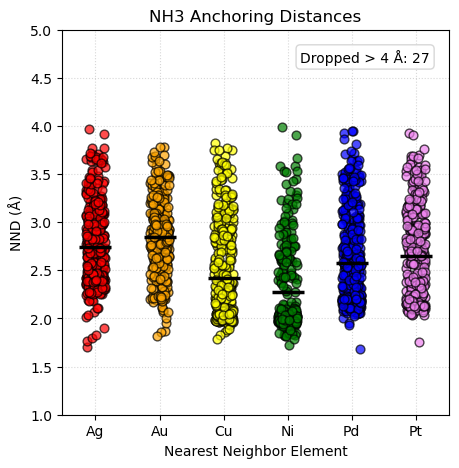

In [13]:
plot_nnd_scatter(images, 'NH3', max_nnd=4)

In [14]:
len(images)

10000

all code written by anywallsocket